In [1]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt

RAW = '../data/regular_linie_week.csv'
DROP_THRESHOLD = 100

In [2]:
df = (
    pl.read_csv(RAW, columns=['tst_iso', 'fzg_id', 'distanz', 'tuerkriterium'])
    .with_columns(pl.col('tst_iso').str.to_datetime(format='%Y-%m-%dT%H:%M:%S%.f%z'))
    .sort(['fzg_id', 'tst_iso'])
    .with_columns([
        pl.int_range(pl.len()).over('fzg_id').alias('row_idx'),
        pl.col('distanz').diff().over('fzg_id').alias('delta'),
        (
            (pl.col('tuerkriterium').shift(1).over('fzg_id') == True) &
            (pl.col('tuerkriterium') == False)
        ).alias('is_door_close'),
        (
            (pl.col('distanz').diff().over('fzg_id') < -DROP_THRESHOLD)
            .cast(pl.Int32).cum_sum().over('fzg_id')
        ).alias('drop_segment'),
    ])
)

print(f'Total rows: {len(df):,}  |  Vehicles: {df["fzg_id"].n_unique()}')
print(f'Drops:      {df.filter(pl.col("delta") < -DROP_THRESHOLD).height:,}')

Total rows: 10,869,683  |  Vehicles: 538
Drops:      1,021,431


## 1. Inter-drop interval（两次 drop 之间的行数和秒数）

In [3]:
drops = (
    df.filter(pl.col('delta') < -DROP_THRESHOLD)
    .with_columns([
        pl.col('row_idx').diff().over('fzg_id').alias('row_interval'),
        pl.col('tst_iso').diff().over('fzg_id').dt.total_seconds().alias('time_interval'),
    ])
)

ri = drops['row_interval'].drop_nulls().to_numpy()
ti = drops['time_interval'].drop_nulls().to_numpy()

pcts = [25, 50, 75, 90, 95, 99]
print(f'{"":5s}  {"rows":>8s}  {"seconds":>10s}')
print('-' * 30)
for p in pcts:
    print(f'p{p:<4d}  {np.percentile(ri, p):>8.1f}  {np.percentile(ti, p):>10.1f}')

per_vehicle_n = (
    drops.group_by('fzg_id')
    .agg(pl.col('row_interval').median().alias('med'))
    .with_columns(
        pl.col('med')
        .map_elements(lambda m: int(np.clip(m / 2, 3, 10)), return_dtype=pl.Int32)
        .alias('n')
    )
)
print()
print('=== n distribution across vehicles ===')
print(per_vehicle_n['n'].value_counts().sort('n'))

           rows     seconds
------------------------------
p25         6.0        54.0
p50         8.0        75.0
p75        11.0       104.0
p90        15.0       149.0
p95        20.0       213.0
p99        73.0      1021.0

=== n distribution across vehicles ===
shape: (3, 2)
┌─────┬───────┐
│ n   ┆ count │
│ --- ┆ ---   │
│ i32 ┆ u32   │
╞═════╪═══════╡
│ 3   ┆ 134   │
│ 4   ┆ 209   │
│ 5   ┆ 23    │
└─────┴───────┘


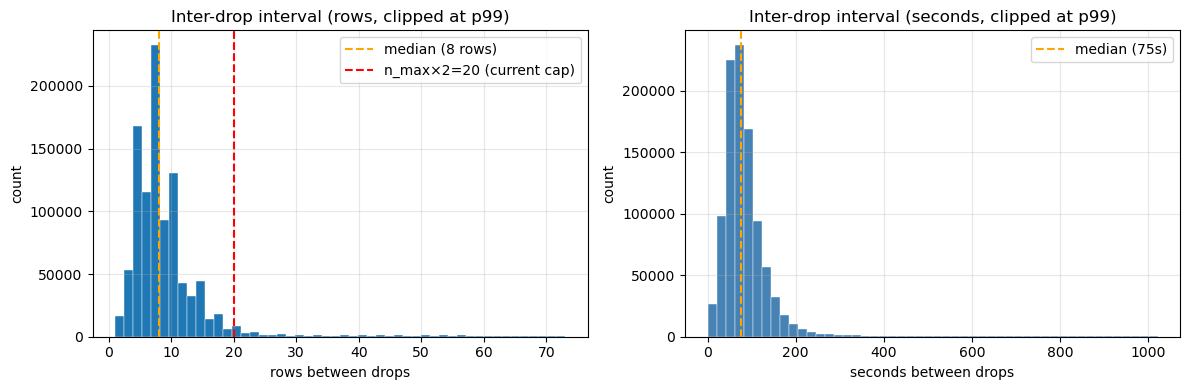

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ri_clip = ri[ri <= np.percentile(ri, 99)]
axes[0].hist(ri_clip, bins=50, edgecolor='white', linewidth=0.3)
axes[0].axvline(np.median(ri), color='orange', linestyle='--', label=f'median ({np.median(ri):.0f} rows)')
axes[0].axvline(20, color='red', linestyle='--', label='n_max×2=20 (current cap)')
axes[0].set_xlabel('rows between drops')
axes[0].set_ylabel('count')
axes[0].set_title('Inter-drop interval (rows, clipped at p99)')
axes[0].legend()
axes[0].grid(alpha=0.3)

ti_clip = ti[ti <= np.percentile(ti, 99)]
axes[1].hist(ti_clip, bins=50, edgecolor='white', linewidth=0.3, color='steelblue')
axes[1].axvline(np.median(ti), color='orange', linestyle='--', label=f'median ({np.median(ti):.0f}s)')
axes[1].set_xlabel('seconds between drops')
axes[1].set_ylabel('count')
axes[1].set_title('Inter-drop interval (seconds, clipped at p99)')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 2. Drop 之后关门发生在第几行？

In [5]:
drop_rows = (
    df.filter(pl.col('delta') < -DROP_THRESHOLD)
    .select(['fzg_id', 'drop_segment', 'row_idx'])
    .rename({'row_idx': 'drop_row_idx'})
)

last_close_rows = (
    df.filter(pl.col('is_door_close'))
    .group_by(['fzg_id', 'drop_segment'])
    .agg(pl.col('row_idx').max().alias('last_close_row_idx'))
)

segments = (
    drop_rows.join(last_close_rows, on=['fzg_id', 'drop_segment'], how='left')
    .with_columns(
        (pl.col('last_close_row_idx') - pl.col('drop_row_idx')).alias('rows_to_close')
    )
)

total   = len(segments)
n_close = segments['rows_to_close'].drop_nulls().len()
rtc     = segments['rows_to_close'].drop_nulls().to_numpy()

print(f'Stops with door close:    {n_close:,} / {total:,}  ({n_close/total*100:.1f}%)')
print(f'Stops WITHOUT door close: {total - n_close:,}  ({(total-n_close)/total*100:.1f}%)')
print()
print(f'{"":5s}  {"rows_to_close":>15s}')
print('-' * 25)
for p in [50, 75, 90, 95, 99]:
    print(f'p{p:<4d}  {np.percentile(rtc, p):>15.0f}')

Stops with door close:    767,025 / 1,021,431  (75.1%)
Stops WITHOUT door close: 254,406  (24.9%)

         rows_to_close
-------------------------
p50                  0
p75                  2
p90                  4
p95                  9
p99                 70


## 3. 窗口大小 vs 覆盖率

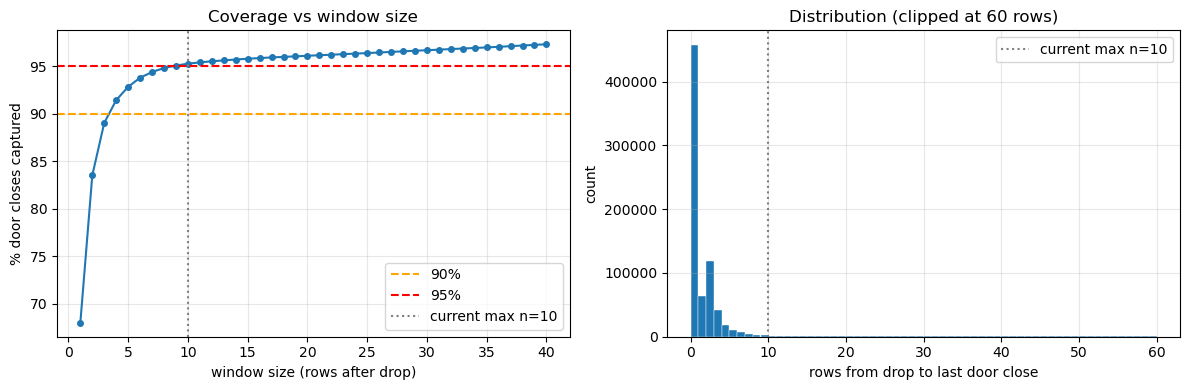

   n    coverage
------------------
   5       92.8%
  10       95.3%
  15       95.8%
  20       96.1%
  25       96.4%
  30       96.7%


In [6]:
ns       = np.arange(1, 41)
coverage = [np.mean(rtc <= n) * 100 for n in ns]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(ns, coverage, marker='o', markersize=4)
axes[0].axhline(90, color='orange', linestyle='--', label='90%')
axes[0].axhline(95, color='red',    linestyle='--', label='95%')
axes[0].axvline(10, color='grey',   linestyle=':',  label='current max n=10')
axes[0].set_xlabel('window size (rows after drop)')
axes[0].set_ylabel('% door closes captured')
axes[0].set_title('Coverage vs window size')
axes[0].legend()
axes[0].grid(alpha=0.3)

clip = rtc[rtc <= 60]
axes[1].hist(clip, bins=60, edgecolor='white', linewidth=0.3)
axes[1].axvline(10, color='grey', linestyle=':', label='current max n=10')
axes[1].set_xlabel('rows from drop to last door close')
axes[1].set_ylabel('count')
axes[1].set_title('Distribution (clipped at 60 rows)')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


print(f'{"n":>4s}  {"coverage":>10s}')
print('-' * 18)
for n in [5, 10, 15, 20, 25, 30]:
    print(f'{n:>4d}  {np.mean(rtc <= n)*100:>9.1f}%')

## 4. 无关门事件停站的 distanz drop 大小分布

In [7]:
# 找出无关门事件的停站（segments 里 rows_to_close 为 null）
no_door_segments = segments.filter(pl.col('rows_to_close').is_null())

# 取对应 drop 行的 delta（drop size）
drop_delta = (
    df.filter(pl.col('delta') < -DROP_THRESHOLD)
    .select(['fzg_id', 'drop_segment', 'delta'])
)

no_door_delta = (
    no_door_segments
    .join(drop_delta, on=['fzg_id', 'drop_segment'], how='left')
    .with_columns(pl.col('delta').abs().alias('drop_size'))
)

drop_size = no_door_delta['drop_size'].drop_nulls().to_numpy()

# 有关门事件的停站 drop size（对比用）
with_door_delta = (
    segments.filter(pl.col('rows_to_close').is_not_null())
    .join(drop_delta, on=['fzg_id', 'drop_segment'], how='left')
    .with_columns(pl.col('delta').abs().alias('drop_size'))
)
drop_size_door = with_door_delta['drop_size'].drop_nulls().to_numpy()

print('=== 无关门事件：drop size (metres) ===')
for p in [25, 50, 75, 90, 95, 99, 100]:
    print(f'  p{p:<3d}: {np.percentile(drop_size, p):>8.0f} m')

print()
print('=== 有关门事件（对比）：drop size (metres) ===')
for p in [25, 50, 75, 90, 95, 99, 100]:
    print(f'  p{p:<3d}: {np.percentile(drop_size_door, p):>8.0f} m')

=== 无关门事件：drop size (metres) ===
  p25 :      259 m
  p50 :      361 m
  p75 :      499 m
  p90 :      651 m
  p95 :      799 m
  p99 :     1142 m
  p100:    21235 m

=== 有关门事件（对比）：drop size (metres) ===
  p25 :      306 m
  p50 :      405 m
  p75 :      517 m
  p90 :      642 m
  p95 :      743 m
  p99 :     1033 m
  p100:    20150 m


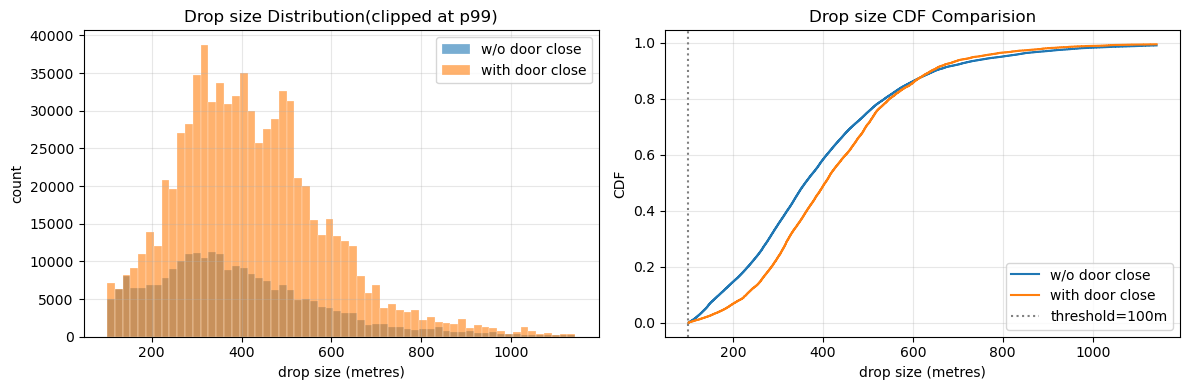

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

clip_val = np.percentile(drop_size, 99)

axes[0].hist(drop_size[drop_size <= clip_val], bins=60,
             alpha=0.6, label='w/o door close', edgecolor='white', linewidth=0.3)
axes[0].hist(drop_size_door[drop_size_door <= clip_val], bins=60,
             alpha=0.6, label='with door close', edgecolor='white', linewidth=0.3)
axes[0].set_xlabel('drop size (metres)')
axes[0].set_ylabel('count')
axes[0].set_title('Drop size Distribution(clipped at p99)')
axes[0].legend()
axes[0].grid(alpha=0.3)

# 右图：CDF 对比
for arr, label in [(drop_size, 'w/o door close'), (drop_size_door, 'with door close')]:
    arr_s = np.sort(arr)
    cdf = np.arange(1, len(arr_s) + 1) / len(arr_s)
    axes[1].plot(arr_s[arr_s <= clip_val],
                 cdf[arr_s <= clip_val], label=label)
axes[1].axvline(DROP_THRESHOLD, color='grey', linestyle=':', label=f'threshold={DROP_THRESHOLD}m')
axes[1].set_xlabel('drop size (metres)')
axes[1].set_ylabel('CDF')
axes[1].set_title('Drop size CDF Comparision')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [9]:
# 读取 stop events，筛出 no_door，取当天数据样本
stop_events = pl.read_parquet('../data/processed/core_stop_events.parquet')

no_door = (
    stop_events
    .filter(pl.col('stop_status') == 'no_door')
    .filter(pl.col('fzg_id').is_in(df['fzg_id'].unique()))  # 只取 CSV 当天有的车
)

print(f'no_door events (当天): {len(no_door):,}')

samples = no_door.sample(10, seed=42)

for row in samples.iter_rows(named=True):
    vid          = row['fzg_id']
    drop_row_idx = row['drop_row_idx']

    window = (
        df.filter(pl.col('fzg_id') == vid)
        .filter(pl.col('row_idx').is_between(drop_row_idx - 4, drop_row_idx + 4))
        .select(['row_idx', 'tst_iso', 'distanz', 'delta', 'tuerkriterium'])
        .sort('row_idx')
    )

    print(f'\nfzg_id={vid}  drop_row_idx={drop_row_idx}')
    print(window)

no_door events (当天): 173,930

fzg_id=2321  drop_row_idx=11798
shape: (9, 5)
┌─────────┬────────────────────────────────┬─────────┬───────┬───────────────┐
│ row_idx ┆ tst_iso                        ┆ distanz ┆ delta ┆ tuerkriterium │
│ ---     ┆ ---                            ┆ ---     ┆ ---   ┆ ---           │
│ i64     ┆ datetime[μs, UTC]              ┆ i64     ┆ i64   ┆ bool          │
╞═════════╪════════════════════════════════╪═════════╪═══════╪═══════════════╡
│ 11794   ┆ 2025-07-29 16:55:06.514986 UTC ┆ 391     ┆ 194   ┆ false         │
│ 11795   ┆ 2025-07-29 16:55:23.513335 UTC ┆ 477     ┆ 86    ┆ false         │
│ 11796   ┆ 2025-07-29 16:55:36.522881 UTC ┆ 524     ┆ 47    ┆ false         │
│ 11797   ┆ 2025-07-29 16:55:51.524071 UTC ┆ 575     ┆ 51    ┆ false         │
│ 11798   ┆ 2025-07-29 16:56:01.526873 UTC ┆ 15      ┆ -560  ┆ false         │
│ 11799   ┆ 2025-07-29 16:56:02.509761 UTC ┆ 15      ┆ 0     ┆ false         │
│ 11800   ┆ 2025-07-29 16:56:13.522258 UTC ┆ 130     ┆ 

/var/folders/jg/lxcfp6vx34d70nm8knsjxpsc0000gn/T/ipykernel_25289/344954452.py:7: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
  .filter(pl.col('fzg_id').is_in(df['fzg_id'].unique()))  # 只取 CSV 当天有的车


In [10]:
# 读取 stop events，筛出 normal stop events，取当天数据样本
# stop_events = pl.read_parquet('../data/processed/core_stop_events.parquet')

normal = (
    stop_events
    .filter(pl.col('stop_status') == 'normal')
    .filter(pl.col('fzg_id').is_in(df['fzg_id'].unique()))  # 只取 CSV 当天有的车
)

print(f'normal events (当天): {len(normal):,}')

samples = normal.sample(10, seed=42)

for row in samples.iter_rows(named=True):
    vid          = row['fzg_id']
    drop_row_idx = row['drop_row_idx']

    window = (
        df.filter(pl.col('fzg_id') == vid)
        .filter(pl.col('row_idx').is_between(drop_row_idx - 4, drop_row_idx + 4))
        .select(['row_idx', 'tst_iso', 'distanz', 'delta', 'tuerkriterium'])
        .sort('row_idx')
    )

    print(f'\nfzg_id={vid}  drop_row_idx={drop_row_idx}')
    print(window)

/var/folders/jg/lxcfp6vx34d70nm8knsjxpsc0000gn/T/ipykernel_25289/296214587.py:7: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
  .filter(pl.col('fzg_id').is_in(df['fzg_id'].unique()))  # 只取 CSV 当天有的车


normal events (当天): 817,806

fzg_id=2151  drop_row_idx=35546
shape: (9, 5)
┌─────────┬────────────────────────────────┬─────────┬───────┬───────────────┐
│ row_idx ┆ tst_iso                        ┆ distanz ┆ delta ┆ tuerkriterium │
│ ---     ┆ ---                            ┆ ---     ┆ ---   ┆ ---           │
│ i64     ┆ datetime[μs, UTC]              ┆ i64     ┆ i64   ┆ bool          │
╞═════════╪════════════════════════════════╪═════════╪═══════╪═══════════════╡
│ 35542   ┆ 2025-08-03 07:59:02.828679 UTC ┆ 237     ┆ 0     ┆ true          │
│ 35543   ┆ 2025-08-03 07:59:04.833630 UTC ┆ 15      ┆ -222  ┆ false         │
│ 35544   ┆ 2025-08-03 07:59:20.849045 UTC ┆ 140     ┆ 125   ┆ false         │
│ 35545   ┆ 2025-08-03 07:59:35.835365 UTC ┆ 273     ┆ 133   ┆ false         │
│ 35546   ┆ 2025-08-03 07:59:47.840962 UTC ┆ 0       ┆ -273  ┆ true          │
│ 35547   ┆ 2025-08-03 07:59:48.836261 UTC ┆ 0       ┆ 0     ┆ true          │
│ 35548   ┆ 2025-08-03 08:00:00.847363 UTC ┆ 314     ┆ 3